Using device: cuda
Starting Training & Validation...
Epoch [1/5] -> Train Acc: 50.18% | Val Acc: 69.23%
Epoch [2/5] -> Train Acc: 95.97% | Val Acc: 75.64%
Epoch [3/5] -> Train Acc: 98.17% | Val Acc: 88.46%
Epoch [4/5] -> Train Acc: 98.72% | Val Acc: 87.18%
Epoch [5/5] -> Train Acc: 99.82% | Val Acc: 93.59%

Final Test Accuracy: 88.46%



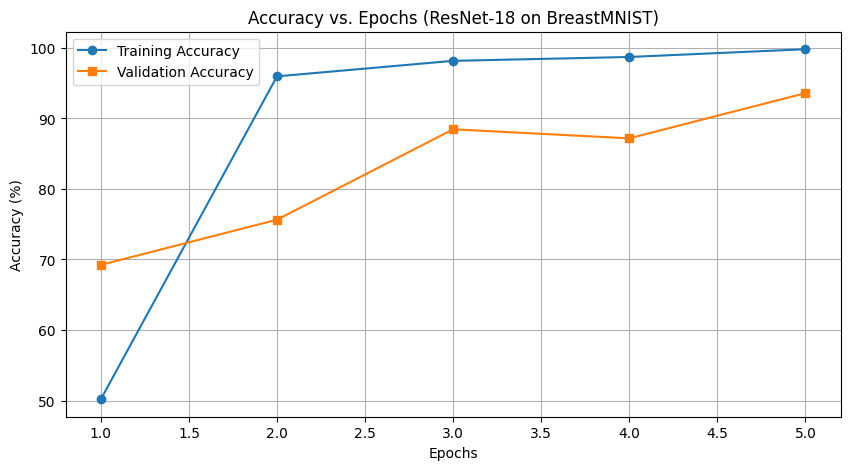

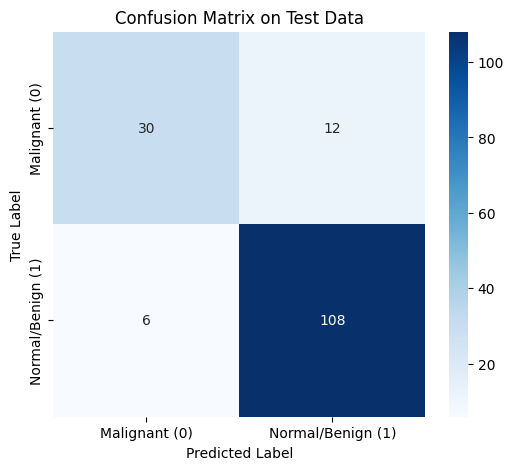

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import medmnist
from medmnist import INFO

# ۱. تنظیمات اولیه و دستگاه
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ۲. آماده‌سازی داده‌ها (پیش‌پردازش برای ResNet)
data_transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)), # تبدیل 1 کانال به 3 کانال
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

info = INFO['breastmnist']
DataClass = getattr(medmnist, info['python_class'])

train_dataset = DataClass(split='train', transform=data_transform, download=True)
val_dataset = DataClass(split='val', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ۳. آماده‌سازی مدل ResNet-18
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2) # تنظیم برای 2 کلاس
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# ۴. حلقه‌ی آموزش و اعتبارسنجی
num_epochs = 5
train_acc_history = []
val_acc_history = []

print("Starting Training & Validation...")
for epoch in range(num_epochs):
    # فاز آموزش
    model.train()
    correct_train, total_train = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.squeeze().long().to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct_train / total_train
    train_acc_history.append(train_acc)
    
    # فاز اعتبارسنجی
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.squeeze().long().to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    val_acc = 100. * correct_val / total_val
    val_acc_history.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# ۵. ارزیابی نهایی روی داده‌های Test
model.eval()
correct_test, total_test = 0, 0
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.squeeze().long().to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_acc = 100. * correct_test / total_test
print(f"\n{'='*40}")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"{'='*40}\n")

# ۶. رسم نمودارها
# الف: نمودار دقت
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_acc_history, label='Training Accuracy', marker='o')
plt.plot(range(1, num_epochs+1), val_acc_history, label='Validation Accuracy', marker='s')
plt.title('Accuracy vs. Epochs (ResNet-18 on BreastMNIST)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# ب: ماتریس آشفتگی
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant (0)', 'Normal/Benign (1)'], 
            yticklabels=['Malignant (0)', 'Normal/Benign (1)'])
plt.title('Confusion Matrix on Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generator Parameters: 1,079,717
Discriminator Parameters: 141,409
----------------------------------------
Starting Stabilized cDCGAN Training...
[Epoch 10/50] [D loss: 0.5516] [G loss: 1.1026]
[Epoch 20/50] [D loss: 0.3615] [G loss: 1.5889]
[Epoch 30/50] [D loss: 0.2984] [G loss: 1.8923]
[Epoch 40/50] [D loss: 0.4924] [G loss: 1.2532]
[Epoch 50/50] [D loss: 0.6871] [G loss: 0.9432]


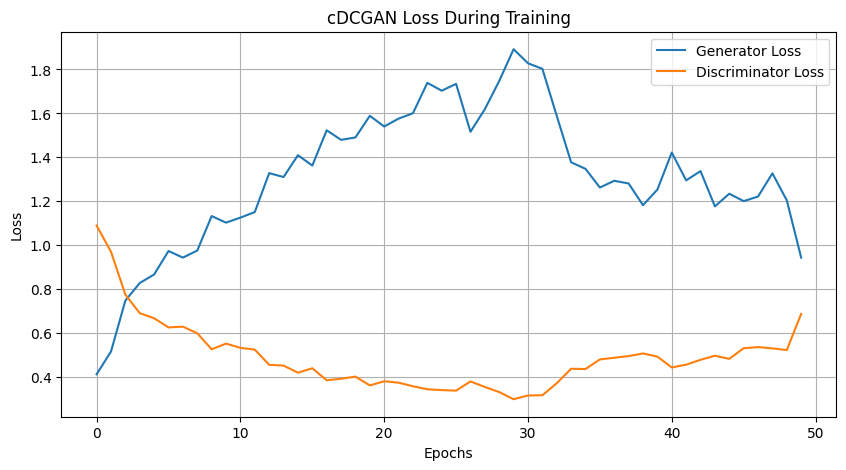


Successfully generated 2000 samples for Class 0 and Class 1.


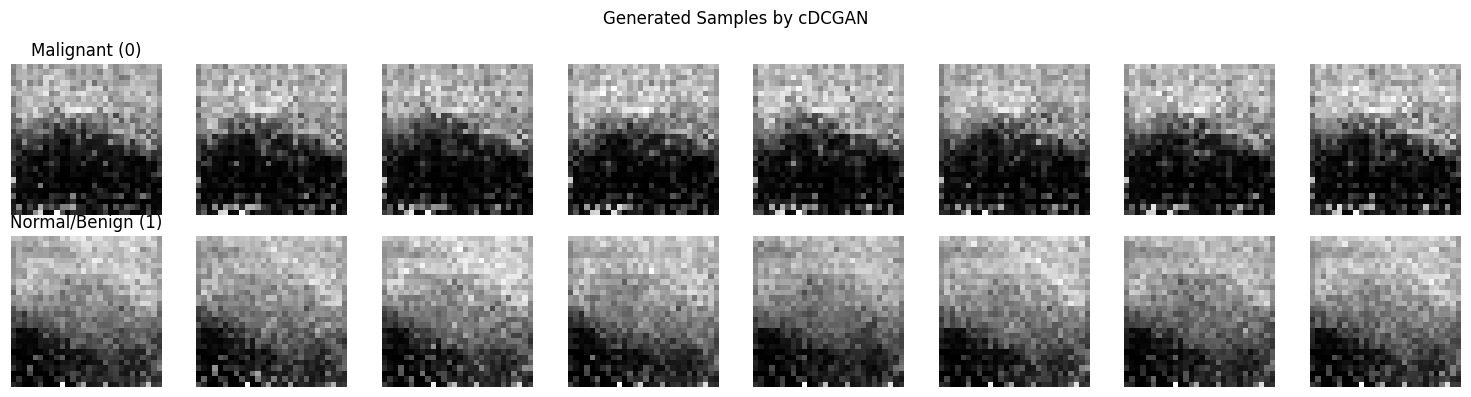

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import medmnist
from medmnist import INFO

# تنظیمات اولیه
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
z_dim = 100
num_classes = 2

# پیش‌پردازش مخصوص GAN (نرمال‌سازی بین -1 و 1 برای لایه Tanh)
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

info = INFO['breastmnist']
DataClass = getattr(medmnist, info['python_class'])
train_dataset_gan = DataClass(split='train', transform=transform_gan, download=False)
train_loader_gan = DataLoader(train_dataset_gan, batch_size=batch_size, shuffle=True)

# ==========================================
# بخش الف: معماری شبکه‌های مولد و تفکیک‌کننده
# ==========================================
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, 50)
        self.init_size = 7
        self.l1 = nn.Sequential(nn.Linear(z_dim + 50, 128 * self.init_size ** 2))
        
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], 1)
        out = self.l1(x)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

class Discriminator(nn.Module):
    def __init__(self, num_classes):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, 28 * 28)
        
        self.model = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels).view(labels.size(0), 1, 28, 28)
        x = torch.cat([img, c], 1)
        validity = self.model(x)
        return validity

# مقداردهی اولیه مدل‌ها
generator = Generator(z_dim, num_classes).to(device)
discriminator = Discriminator(num_classes).to(device)

# محاسبه و چاپ تعداد پارامترها (برای گزارش بخش الف)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Generator Parameters: {count_parameters(generator):,}")
print(f"Discriminator Parameters: {count_parameters(discriminator):,}")
print("-" * 40)

# ==========================================
# بخش ب و ت: آموزش شبکه همراه با راهکارهای پایدارسازی
# ==========================================
criterion = nn.BCELoss()

# راهکار پایدارسازی: D کندتر از G یاد می‌گیرد (TTUR)
lr_G = 0.0002
lr_D = 0.00005 

optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.999))

num_epochs = 50
g_losses, d_losses = [], []

print("Starting Stabilized cDCGAN Training...")
for epoch in range(num_epochs):
    for i, (imgs, labels) in enumerate(train_loader_gan):
        batch_size = imgs.shape[0]
        real_imgs = imgs.to(device)
        labels = labels.squeeze().long().to(device)
        
        # راهکار پایدارسازی: Label Smoothing (استفاده از 0.9 به جای 1.0)
        valid_target = torch.full((batch_size, 1), 0.9, device=device)
        fake_target = torch.zeros(batch_size, 1, device=device)

        # -- آموزش Discriminator --
        optimizer_D.zero_grad()
        real_pred = discriminator(real_imgs, labels)
        d_real_loss = criterion(real_pred, valid_target)
        
        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = generator(z, labels)
        
        fake_pred = discriminator(fake_imgs.detach(), labels)
        d_fake_loss = criterion(fake_pred, fake_target)
        
        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -- آموزش Generator --
        optimizer_G.zero_grad()
        gen_target = torch.ones(batch_size, 1, device=device)
        validity = discriminator(fake_imgs, labels)
        g_loss = criterion(validity, gen_target)
        
        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"[Epoch {epoch+1}/{num_epochs}] [D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

# رسم نمودار Loss
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.title("cDCGAN Loss During Training")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# بخش پ: تولید 2000 نمونه از هر کلاس و نمایش آن‌ها
# ==========================================
generator.eval()
num_samples_per_class = 2000
generated_data = {0: [], 1: []}

with torch.no_grad():
    for class_label in [0, 1]:
        labels = torch.full((num_samples_per_class,), class_label, dtype=torch.long, device=device)
        z = torch.randn(num_samples_per_class, z_dim, device=device)
        gen_imgs = generator(z, labels)
        gen_imgs = (gen_imgs + 1) / 2.0  # تبدیل از [-1, 1] به [0, 1]
        generated_data[class_label] = gen_imgs.cpu()

print(f"\nSuccessfully generated {num_samples_per_class} samples for Class 0 and Class 1.")

# نمایش 8 نمونه از هر کلاس
fig, axes = plt.subplots(2, 8, figsize=(15, 4))
classes_names = ['Malignant (0)', 'Normal/Benign (1)']

for i, class_label in enumerate([0, 1]):
    for j in range(8):
        idx = np.random.randint(0, num_samples_per_class)
        img = generated_data[class_label][idx].squeeze()
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(classes_names[i])

plt.suptitle("Generated Samples by cDCGAN")
plt.tight_layout()
plt.show()

Preparing Combined Balanced Dataset...
Re-initializing ResNet-18...
Starting Training on Combined Dataset...
Epoch [1/5] -> Train Loss: 0.1524 | Train Acc: 92.80%
Epoch [2/5] -> Train Loss: 0.0642 | Train Acc: 97.75%
Epoch [3/5] -> Train Loss: 0.0461 | Train Acc: 98.45%
Epoch [4/5] -> Train Loss: 0.0148 | Train Acc: 99.55%
Epoch [5/5] -> Train Loss: 0.0114 | Train Acc: 99.45%

Final Test Accuracy (with GAN Augmentation): 88.46%



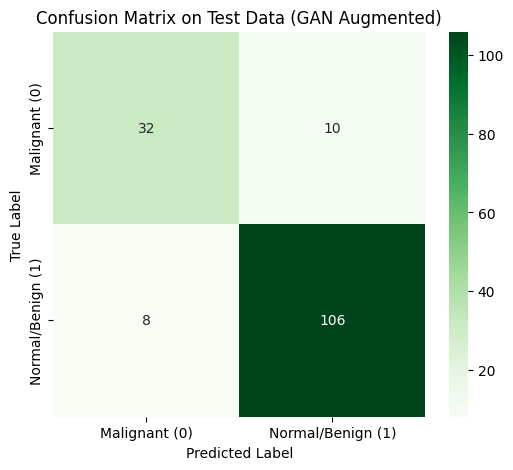

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import medmnist
from medmnist import INFO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Preparing Combined Balanced Dataset...")

# ==========================================
# ۱. استخراج داده‌های آموزشی واقعی
# ==========================================
info = INFO['breastmnist']
DataClass = getattr(medmnist, info['python_class'])

transform_raw = transforms.ToTensor()
raw_train_dataset = DataClass(split='train', transform=transform_raw, download=False)

orig_imgs = []
orig_labels = []
for img, label in raw_train_dataset:
    orig_imgs.append(img)
    orig_labels.append(label.item())

orig_imgs = torch.stack(orig_imgs)
orig_labels = torch.tensor(orig_labels)

orig_c0 = orig_imgs[orig_labels == 0] 
orig_c1 = orig_imgs[orig_labels == 1] 

# ==========================================
# ۲. نمونه‌برداری تصادفی و ترکیب داده‌ها (ایجاد توازن)
# ==========================================
target_size_per_class = 1000

def create_balanced_class(orig_data, gen_data, target_size):
    num_orig = len(orig_data)
    num_gen_needed = target_size - num_orig
    indices = torch.randperm(len(gen_data))[:num_gen_needed]
    selected_gen = gen_data[indices]
    combined = torch.cat([orig_data, selected_gen], dim=0)
    return combined

# فرض بر این است که متغیر generated_data از بخش قبل در حافظه موجود است
combined_c0 = create_balanced_class(orig_c0, generated_data[0], target_size_per_class)
combined_c1 = create_balanced_class(orig_c1, generated_data[1], target_size_per_class)

all_combined_imgs = torch.cat([combined_c0, combined_c1], dim=0)
all_combined_labels = torch.cat([
    torch.zeros(target_size_per_class, dtype=torch.long), 
    torch.ones(target_size_per_class, dtype=torch.long)
])

# ==========================================
# ۳. ساخت Dataset سفارشی با پیش‌پردازش‌های مجزا
# ==========================================
# ترانسفورم مخصوص داده‌های آموزش ترکیبی (که از قبل Tensor هستند)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ترانسفورم مخصوص داده‌های تست (که عکس PIL هستند و نیاز به ToTensor دارند)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.ToTensor(), 
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CombinedDataset(Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

balanced_train_dataset = CombinedDataset(all_combined_imgs, all_combined_labels, transform=train_transforms)
balanced_train_loader = DataLoader(balanced_train_dataset, batch_size=32, shuffle=True)

test_dataset = DataClass(split='test', transform=test_transforms, download=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

# ==========================================
# ۴. بازآموزی ResNet-18 روی مجموعه داده جدید
# ==========================================
print("Re-initializing ResNet-18...")
model_augmented = resnet18(weights=ResNet18_Weights.DEFAULT)
model_augmented.fc = nn.Linear(model_augmented.fc.in_features, 2)
model_augmented = model_augmented.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_augmented.parameters(), lr=0.0001)

num_epochs = 5
print("Starting Training on Combined Dataset...")

for epoch in range(num_epochs):
    model_augmented.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in balanced_train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_augmented(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / len(balanced_train_loader.dataset)
    epoch_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

# ==========================================
# ۵. ارزیابی نهایی و رسم ماتریس آشفتگی
# ==========================================
model_augmented.eval()
correct_test = 0
total_test = 0
all_preds = []
all_targets = []

with torch.no_grad():سس
    for images, labels in test_loader:
        images, labels = images.to(device), labels.squeeze().long().to(device)
        outputs = model_augmented(images)
        _, predicted = outputs.max(1)
        
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_acc = 100. * correct_test / total_test

print(f"\n{'='*50}")
print(f"Final Test Accuracy (with GAN Augmentation): {test_acc:.2f}%")
print(f"{'='*50}\n")

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Malignant (0)', 'Normal/Benign (1)'], 
            yticklabels=['Malignant (0)', 'Normal/Benign (1)'])
plt.title('Confusion Matrix on Test Data (GAN Augmented)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()